In [16]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
#Reading the Dataset
try:
    dataset = pd.read_csv('data/superstore_final_dataset.csv', encoding='latin1')
except UnicodeDecodeError:
    print("Dataset Reading Failed")

In [18]:
#Data Sample
dataset.head(5)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [29]:
print("\n Dataset Shape (Rows, Columns) ---")
print(dataset.shape)

print("\n Data Structure and Missing Values (.info()) ---")
dataset.info()

print("\n Statistical Summary (.describe(include='all')) ---")
# Use include='all' to see statistics for categorical columns as well
print(dataset.describe(include='all'))

#Missing Values and Duplicates
print("\nMissing Values Count:")
print(dataset.isnull().sum())

# Check for duplicates
num_duplicates = dataset.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {num_duplicates}")
if num_duplicates > 0:
    print("Note: Duplicates exist. Consider removing them for aggregate analysis.")



 Dataset Shape (Rows, Columns) ---
(9800, 18)

 Data Structure and Missing Values (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16 

In [34]:
try:
    dataset['Sales'] = pd.to_numeric(dataset['Sales'], errors='coerce')
    dataset = dataset.dropna(subset=['Sales'])
    print(f"Cleaned DataFrame has {len(dataset)} rows after dropping rows with non-numeric sales.")
except Exception as e:
    print(f"Warning: Could not convert Sales to numeric. Error: {e}")

#Feature Engineering: Extract Year and Month for time-series analysis
dataset['Order_Date'] = pd.to_datetime(
    dataset['Order_Date'], 
    format='%d/%m/%Y',
    errors='coerce' # Keep errors='coerce' to turn bad dates into NaT
)

dataset['Order_Year'] = dataset['Order_Date'].dt.year
dataset['Order_Month_Year'] = dataset['Order_Date'].dt.to_period('M')

Cleaned DataFrame has 9800 rows after dropping rows with non-numeric sales.


In [36]:
print("\nSales Descriptive Statistics:")
print(dataset['Sales'].describe().to_string())


Sales Descriptive Statistics:
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000



Top 3 Categories by Sales:
       Category       Sales
     Technology 827455.8730
      Furniture 728658.5757
Office Supplies 705422.3340


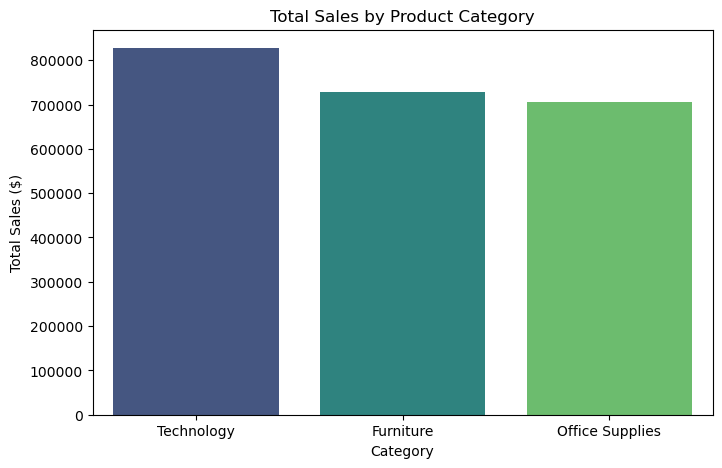

In [40]:
#Sales by Category
sales_by_category = dataset.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
print("\nTop 3 Categories by Sales:")
print(sales_by_category.head(3).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.show()


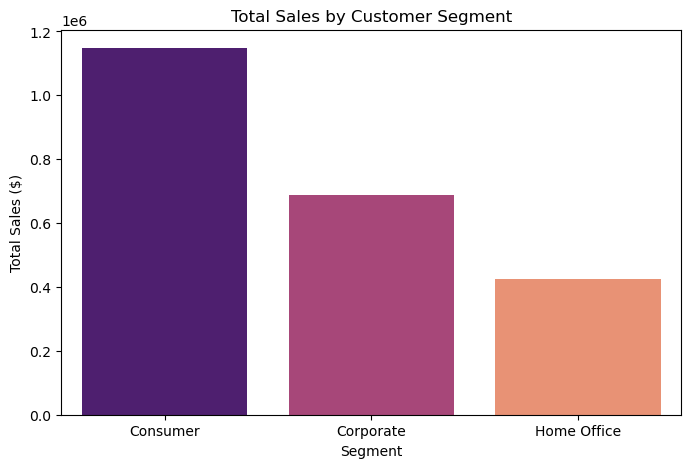

In [41]:
#Sales by Segment
sales_by_segment = dataset.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Segment', y='Sales', data=sales_by_segment, palette='magma')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales ($)')
plt.show()

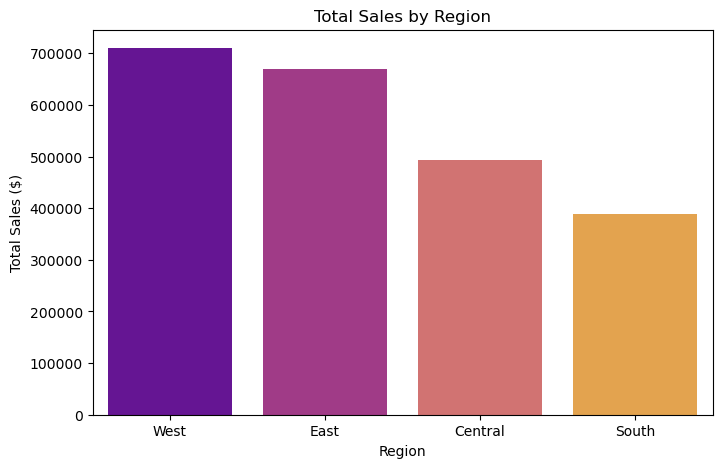

In [42]:
#Sales by Region
sales_by_region = dataset.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='plasma')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.show()

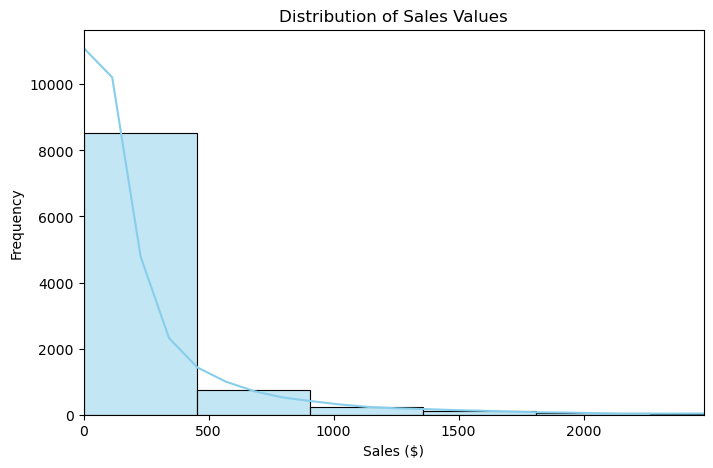

In [43]:
#Sales Distribution (Checking for outliers/skewness)
plt.figure(figsize=(8, 5))
sns.histplot(dataset['Sales'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Sales Values')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.xlim(0, dataset['Sales'].quantile(0.99)) # Limit x-axis to 99th percentile to better show bulk of data
plt.show()

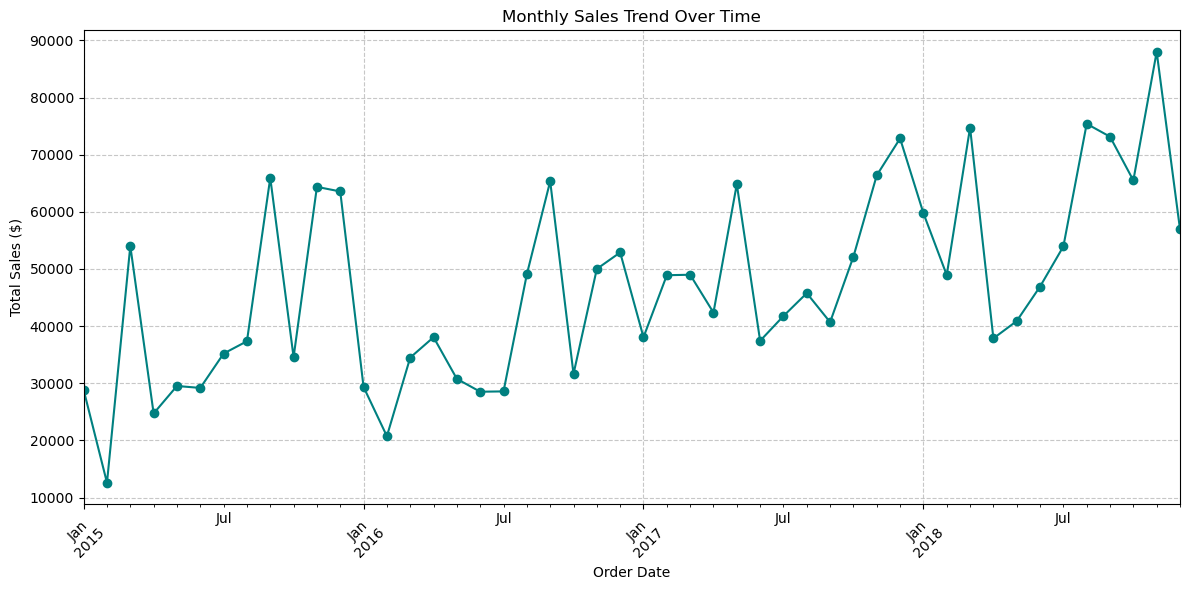

In [45]:
# Correct and simple approach:
plt.figure(figsize=(12, 6))
# Call plot directly on the Series. Pandas handles the time index automatically.
monthly_sales.plot(kind='line', marker='o', linestyle='-', color='teal') 
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()